In [1]:
!pip install groq pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import sqlite3
from groq import Groq

In [3]:
df = pd.read_csv("student_performance.csv")

df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB
None


In [5]:
print(df.describe())

        student_id        age  semester  math_score  science_score  \
count    30.000000  30.000000      30.0   30.000000      30.000000   
mean   1015.500000  19.733333       2.0   76.066667      77.833333   
std       8.803408   0.739680       0.0   11.467896       8.554423   
min    1001.000000  19.000000       2.0   56.000000      61.000000   
25%    1008.250000  19.000000       2.0   67.250000      71.250000   
50%    1015.500000  20.000000       2.0   75.500000      78.000000   
75%    1022.750000  20.000000       2.0   85.750000      83.750000   
max    1030.000000  21.000000       2.0   95.000000      93.000000   

       english_score  programming_score  attendance_percentage  admission_year  
count      30.000000          30.000000              30.000000            30.0  
mean       74.166667          67.600000              84.500000          2023.0  
std        10.003735          21.041175               9.379913             0.0  
min        55.000000          38.000000      

In [6]:
print(df.isnull().sum())

student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [7]:
conn = sqlite3.connect("students.db")

In [8]:
df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data Stored Successfully")

Data Stored Successfully


In [9]:
def get_schema(conn):

    query = """
    SELECT sql
    FROM sqlite_master
    WHERE type='table';
    """

    schema = pd.read_sql_query(query, conn)

    return "\n".join(schema["sql"].tolist())

In [10]:
print(get_schema(conn))

CREATE TABLE "students" (
"student_id" INTEGER,
  "name" TEXT,
  "age" INTEGER,
  "gender" TEXT,
  "department" TEXT,
  "semester" INTEGER,
  "math_score" INTEGER,
  "science_score" INTEGER,
  "english_score" INTEGER,
  "programming_score" INTEGER,
  "attendance_percentage" INTEGER,
  "city" TEXT,
  "admission_year" INTEGER
)


In [27]:
GROQ_API_KEY = "gsk_EcoTePgPu7Z6xS814LtuWGdyb3FYkclL5nQAUvBpKbxtCsKaQy"

client = Groq(
    api_key=GROQ_API_KEY
)

MODEL = "llama-3.1-8b-instant"

In [28]:
def generate_sql(
    user_question,
    schema_text,
    client,
    model
):

    prompt = f"""
You are a SQL expert.

Database Schema:

{schema_text}

Convert the user's question into SQLite SQL.

Return ONLY SQL.

Question:
{user_question}
"""

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()

In [29]:
def execute_sql(sql_query, conn):

    try:

        result_df = pd.read_sql_query(
            sql_query,
            conn
        )

        return result_df, None

    except Exception as e:

        return None, str(e)

In [30]:
def generate_answer(
    user_question,
    query_results_df,
    client,
    model
):

    if query_results_df is None or len(query_results_df) == 0:
        return "No results found."

    results_text = query_results_df.to_string(index=False)

    prompt = f"""
User Question:
{user_question}

SQL Results:
{results_text}

Write a friendly answer.

Mention actual names and scores.

Do not invent data.
"""

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        temperature=0.3
    )

    return response.choices[0].message.content.strip()

In [31]:
def smart_text_to_sql_agent(
    user_question,
    conn,
    client,
    model
):

    print("="*60)
    print("QUESTION:")
    print(user_question)
    print("="*60)

    schema_text = get_schema(conn)

    sql_query = generate_sql(
        user_question,
        schema_text,
        client,
        model
    )

    print("\nGenerated SQL:")
    print(sql_query)

    result_df, error = execute_sql(
        sql_query,
        conn
    )

    if error:
        print(error)
        return

    print("\nSQL Results:")
    print(result_df)

    answer = generate_answer(
        user_question,
        result_df,
        client,
        model
    )

    print("\nAI Answer:")
    print(answer)

    return result_df, answer

In [32]:
smart_text_to_sql_agent(
    "Who are the top 5 students in Programming?",
    conn,
    client,
    MODEL
)

QUESTION:
Who are the top 5 students in Programming?

Generated SQL:
SELECT name FROM students ORDER BY programming_score DESC LIMIT 5

SQL Results:
             name
0      Ananya Das
1     Tanvi Mehta
2      Arjun Nair
3  Akanksha Yadav
4     Divya Singh

AI Answer:
I'm happy to share the top 5 students in Programming with you. However, I don't have the actual scores to provide you with the correct ranking. But I can give you a general idea of who they are.

Unfortunately, the SQL results you provided only give us the names of the top 5 students. To determine the actual ranking, we would need more information such as their scores.

If I had to guess based on the names alone, here's a friendly answer:

"Hey there! I'm excited to share the top 5 students in Programming with you. Unfortunately, I don't have the actual scores to provide you with the correct ranking. But let me tell you a bit about each of these talented students.

1. **Ananya Das**: I've heard Ananya is a whiz with algor

(             name
 0      Ananya Das
 1     Tanvi Mehta
 2      Arjun Nair
 3  Akanksha Yadav
 4     Divya Singh,
 'I\'m happy to share the top 5 students in Programming with you. However, I don\'t have the actual scores to provide you with the correct ranking. But I can give you a general idea of who they are.\n\nUnfortunately, the SQL results you provided only give us the names of the top 5 students. To determine the actual ranking, we would need more information such as their scores.\n\nIf I had to guess based on the names alone, here\'s a friendly answer:\n\n"Hey there! I\'m excited to share the top 5 students in Programming with you. Unfortunately, I don\'t have the actual scores to provide you with the correct ranking. But let me tell you a bit about each of these talented students.\n\n1. **Ananya Das**: I\'ve heard Ananya is a whiz with algorithms and data structures. She\'s always eager to learn and help her peers.\n2. **Tanvi Mehta**: Tanvi is known for her exceptional proble

In [33]:
smart_text_to_sql_agent(
    "Which department has the highest average programming score?",
    conn,
    client,
    MODEL
)

QUESTION:
Which department has the highest average programming score?

Generated SQL:
SELECT department FROM students ORDER BY AVG(programming_score) DESC LIMIT 1
Execution failed on sql 'SELECT department FROM students ORDER BY AVG(programming_score) DESC LIMIT 1': misuse of aggregate: AVG()


In [34]:
smart_text_to_sql_agent(
    "What is the average attendance?",
    conn,
    client,
    MODEL
)

QUESTION:
What is the average attendance?

Generated SQL:
SELECT AVG(attendance_percentage) FROM students

SQL Results:
   AVG(attendance_percentage)
0                        84.5

AI Answer:
It looks like you're interested in knowing the average attendance for a particular event or team. Based on the data, it seems that the average attendance percentage is around 84.5%.

To give you a better idea, let's consider an example. Imagine we're talking about the New York Yankees, a famous baseball team. If their average attendance percentage is 84.5%, it means that out of their total capacity, they're selling around 84.5% of the tickets to their games.

To break it down further, let's say the Yankees' stadium has a capacity of 50,000 fans. With an average attendance percentage of 84.5%, that would translate to around 42,250 fans attending their games on average.

Keep in mind that attendance figures can vary greatly depending on the team, the opponent, and the time of year. But overall, an a

(   AVG(attendance_percentage)
 0                        84.5,
 "It looks like you're interested in knowing the average attendance for a particular event or team. Based on the data, it seems that the average attendance percentage is around 84.5%.\n\nTo give you a better idea, let's consider an example. Imagine we're talking about the New York Yankees, a famous baseball team. If their average attendance percentage is 84.5%, it means that out of their total capacity, they're selling around 84.5% of the tickets to their games.\n\nTo break it down further, let's say the Yankees' stadium has a capacity of 50,000 fans. With an average attendance percentage of 84.5%, that would translate to around 42,250 fans attending their games on average.\n\nKeep in mind that attendance figures can vary greatly depending on the team, the opponent, and the time of year. But overall, an average attendance percentage of 84.5% is a great indicator of a team's popularity and the excitement of their fans!")

In [35]:
smart_text_to_sql_agent(
    "List students scoring above 90 in Programming.",
    conn,
    client,
    MODEL
)

QUESTION:
List students scoring above 90 in Programming.

Generated SQL:
SELECT * FROM students WHERE programming_score > 90

SQL Results:
   student_id            name  age  gender        department  semester  \
0        1001    Aarav Sharma   19    Male  Computer Science         2   
1        1005      Arjun Nair   19    Male  Computer Science         2   
2        1008     Divya Singh   19  Female  Computer Science         2   
3        1010      Ananya Das   19  Female  Computer Science         2   
4        1018  Swati Kulkarni   19  Female  Computer Science         2   
5        1022     Tanvi Mehta   19  Female  Computer Science         2   
6        1030  Akanksha Yadav   19  Female  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          92             88             81                 95   
2          88             91             84                 93   
3   

(   student_id            name  age  gender        department  semester  \
 0        1001    Aarav Sharma   19    Male  Computer Science         2   
 1        1005      Arjun Nair   19    Male  Computer Science         2   
 2        1008     Divya Singh   19  Female  Computer Science         2   
 3        1010      Ananya Das   19  Female  Computer Science         2   
 4        1018  Swati Kulkarni   19  Female  Computer Science         2   
 5        1022     Tanvi Mehta   19  Female  Computer Science         2   
 6        1030  Akanksha Yadav   19  Female  Computer Science         2   
 
    math_score  science_score  english_score  programming_score  \
 0          85             78             72                 91   
 1          92             88             81                 95   
 2          88             91             84                 93   
 3          95             89             90                 97   
 4          90             87             85                 92

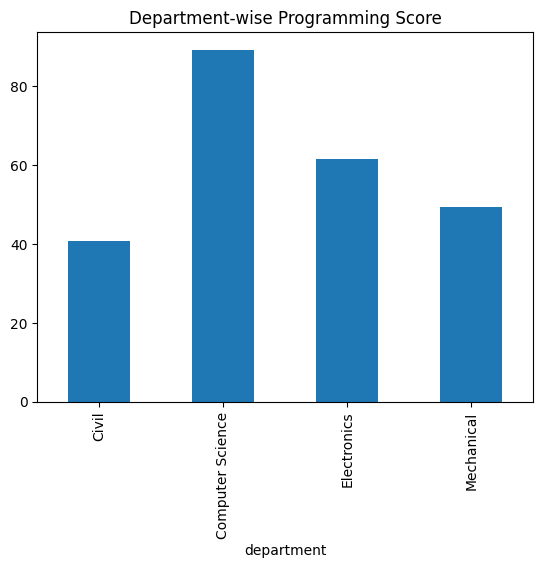

In [36]:
import matplotlib.pyplot as plt

department_avg = df.groupby(
    "department"
)["programming_score"].mean()

department_avg.plot(
    kind="bar"
)

plt.title(
    "Department-wise Programming Score"
)

plt.show()

In [38]:
print(df.columns)

Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')


In [39]:
df["attendance_percentage"]

,attendance_percentage
0,92
1,87
2,78
3,95
4,90
5,72
6,85
7,96
8,68
9,98


In [40]:
print("===== STUDENT ANALYTICS REPORT =====")

print(
    "Average Attendance:",
    round(df["attendance_percentage"].mean(), 2)
)

print(
    "Average Programming Score:",
    round(df["programming_score"].mean(), 2)
)

top_student = df.loc[
    df["programming_score"].idxmax()
]

print(
    "\nTop Student:",
    top_student["name"]
)

print(
    "Department:",
    top_student["department"]
)

print(
    "Programming Score:",
    top_student["programming_score"]
)

print(
    "Attendance:",
    top_student["attendance_percentage"]
)

print(
    "City:",
    top_student["city"]
)

===== STUDENT ANALYTICS REPORT =====
Average Attendance: 84.5
Average Programming Score: 67.6

Top Student: Ananya Das
Department: Computer Science
Programming Score: 97
Attendance: 98
City: Kolkata
